In [1]:
#part 2 
import torch
import numpy as np

In [52]:
# Use NumPy to create a 2 D array of complex numbers on [ -2 ,2] x [ -2 ,2]
Y , X = np . mgrid [ -1.3:1.3:0.005 , -2:1:0.005]
x = torch . Tensor ( X )
y = torch . Tensor ( Y )
z = torch . complex (x , y ) # important !
zs = z . clone () # Updated !
ns = torch . zeros_like ( z )

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
z = z . to ( device )
zs = zs . to ( device )
ns = ns . to ( device )

NameError: name 'z' is not defined

In [47]:
# Mandelbrot Set
for i in range (200) :
    # Compute the new values of z : z ^2 + x
    zs_ = zs * zs + z
    # Have we diverged with this new value ?
    not_diverged = torch . abs ( zs_ ) < 4.0
    # Update variables to compute
    ns += not_diverged
    zs = zs_

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

C:\Users\keith\AppData\Local\Temp\ipykernel_21300\1271138250.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np . uint8 ( np . clip (a , 0 , 255) )


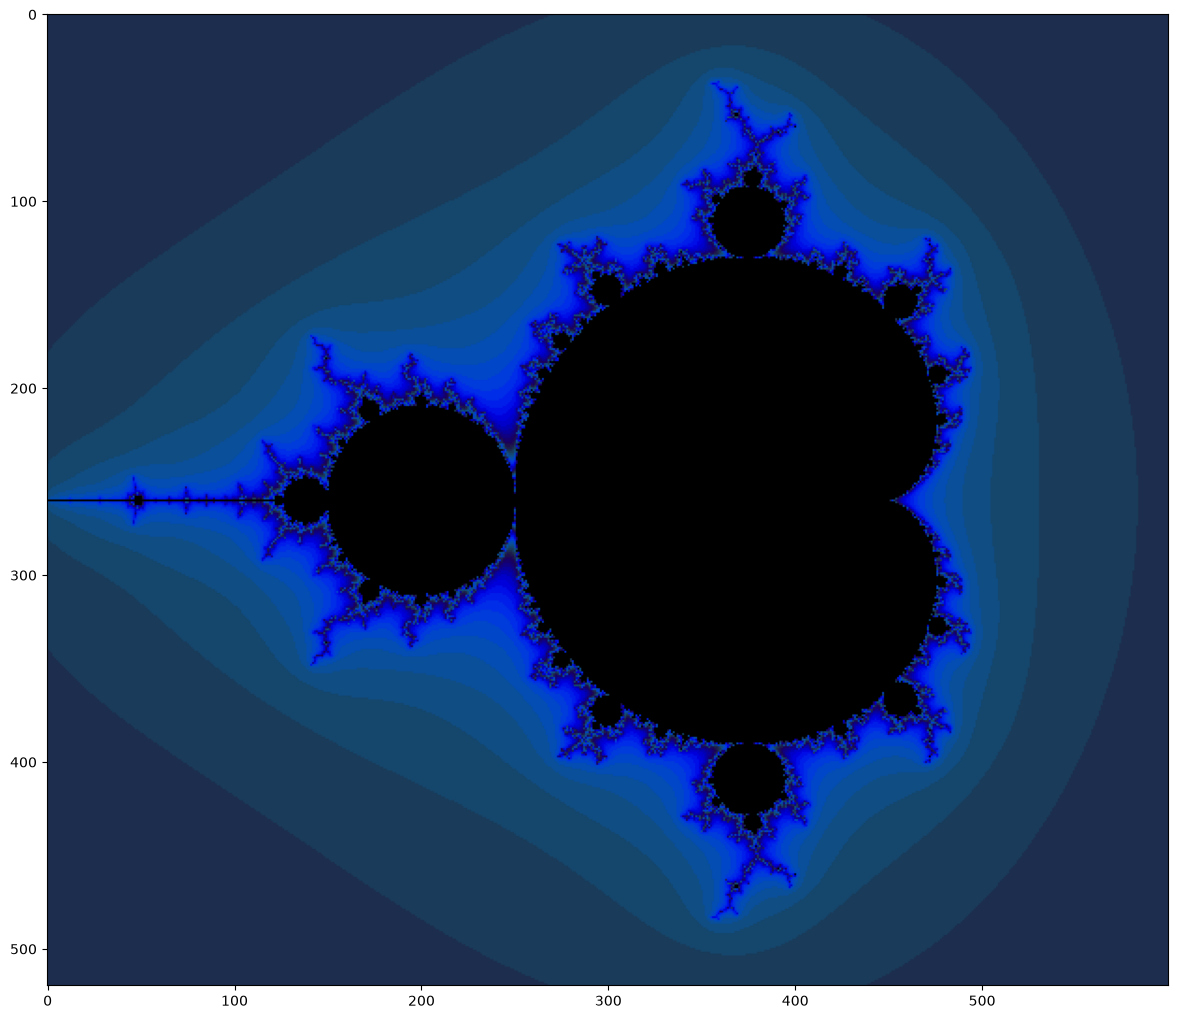

In [19]:
# plot
import matplotlib . pyplot as plt
fig = plt . figure ( figsize =(16 ,10) )
def processFractal ( a ) :
    # Display an array of iteration counts as a
    # colorful picture of a fractal . 
    a_cyclic = (6.28* a /20.0) . reshape ( list ( a . shape ) +[1])
    img = np . concatenate ([10+20* np . cos ( a_cyclic ) ,
    30+50* np . sin ( a_cyclic ) ,
    155 -80* np . cos ( a_cyclic ) ] , 2)
    img [ a == a . max () ] = 0
    a = img
    a = np . uint8 ( np . clip (a , 0 , 255) )
    return a
plt . imshow ( processFractal ( ns . cpu () . numpy () ) )
plt . tight_layout ( pad =0)
plt . show ()

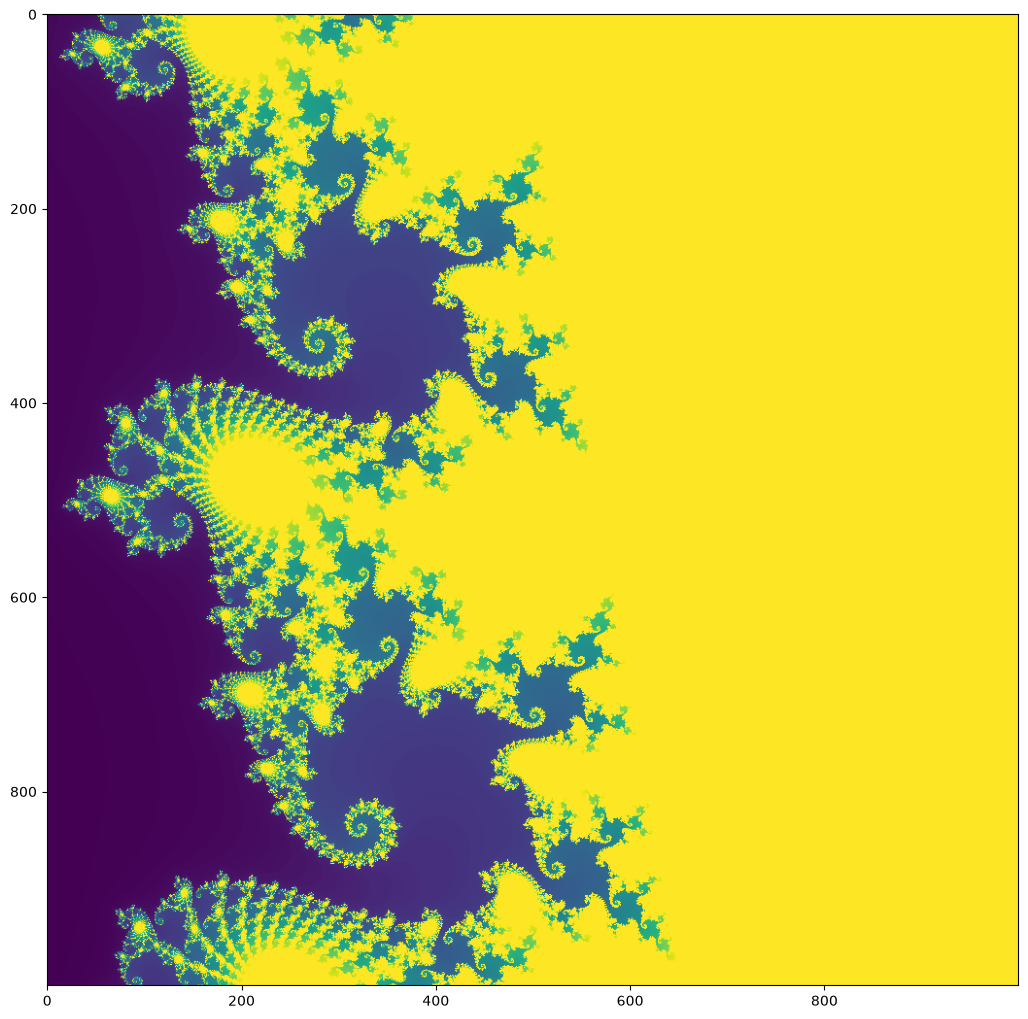

In [44]:
fig = plt . figure ( figsize =(16 ,10) )

def zooming_mandelbrot(x_min, x_max, y_min, y_max,resolution=1000, max_iter=200,
                     device=device, show=True):
    Y, X = np.mgrid[y_min:y_max:resolution * 1j, x_min:x_max:resolution * 1j]
    z = torch.complex(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(Y, dtype=torch.float32)).to(device)
    zs = z.clone()
    ns = torch.zeros_like(z, dtype=torch.float32)

    for i in range(max_iter):
        zs_ = zs * zs + z
        not_diverged = torch.abs(zs_) < 4.0
        ns += not_diverged
        zs = zs_

    return ns

img = zooming_mandelbrot(-0.75, -0.735, 0.10, 0.115, resolution=1000, max_iter=200).detach().cpu().numpy()
plt.imshow(img)
plt . tight_layout ( pad =0)
plt . show ()

In [12]:
#julia set
Y , X = np . mgrid [ -1.3:1.3:0.005 , -2:1:0.005]
x = torch . Tensor ( X )
y = torch . Tensor ( Y )
z = torch . complex (x , y ) # important !

zs = z . clone () # Updated !
ns = torch . zeros_like ( z )
z = torch.tensor(-0.7 + 0.27j, device=device)

z = z . to ( device )
zs = zs . to ( device )
ns = ns . to ( device )

In [13]:

for i in range(200):
    zs_ = zs * zs + z
    not_diverged = torch.abs(zs_) < 4.0
    ns += not_diverged
    zs = zs_

C:\Users\keith\AppData\Local\Temp\ipykernel_26920\1271138250.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np . uint8 ( np . clip (a , 0 , 255) )


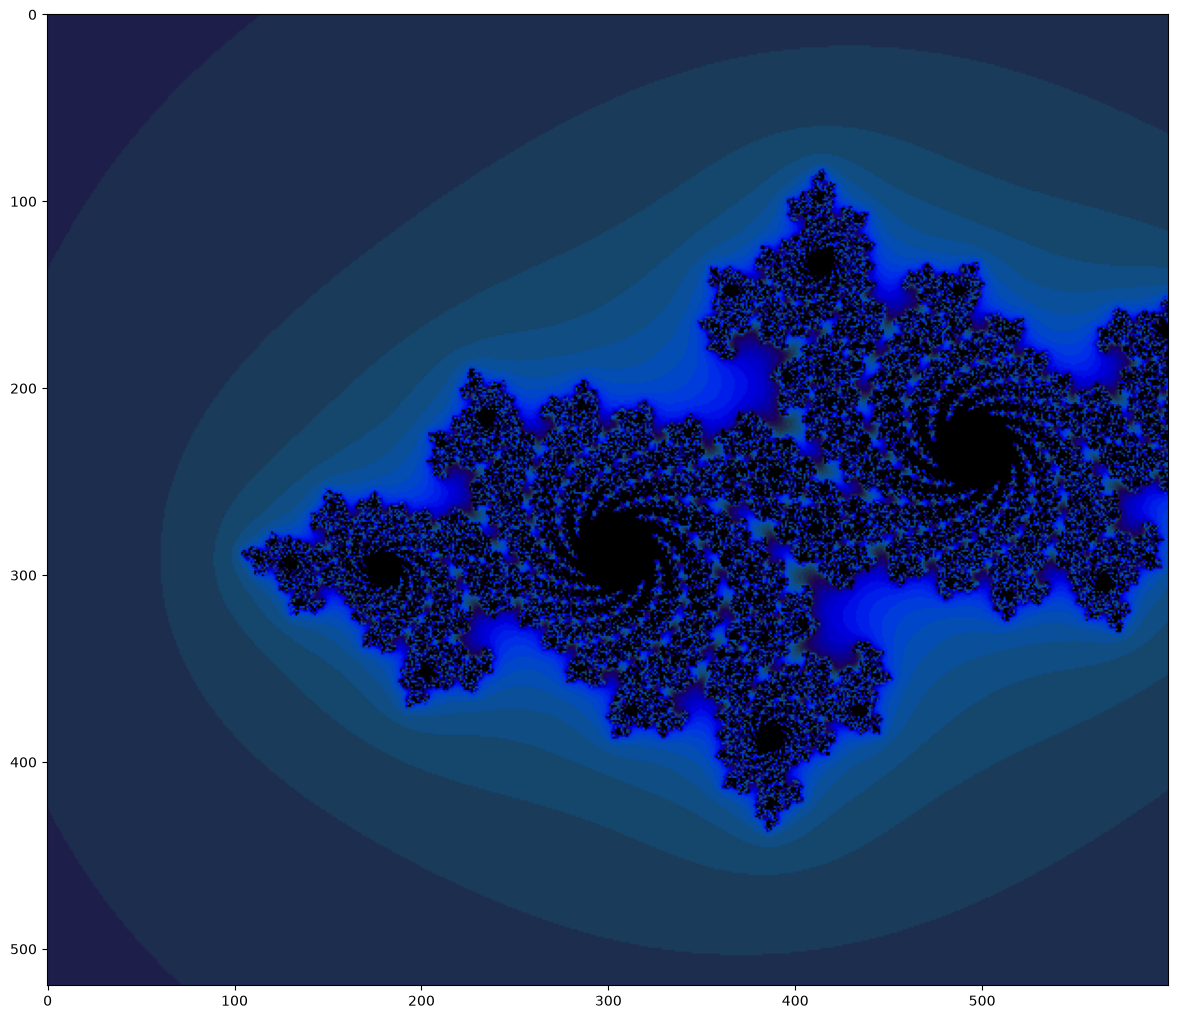

In [14]:
# plot
import matplotlib . pyplot as plt
fig = plt . figure ( figsize =(16 ,10) )
def processFractal ( a ) :
    # Display an array of iteration counts as a
    # colorful picture of a fractal . 
    a_cyclic = (6.28* a /20.0) . reshape ( list ( a . shape ) +[1])
    img = np . concatenate ([10+20* np . cos ( a_cyclic ) ,
    30+50* np . sin ( a_cyclic ) ,
    155 -80* np . cos ( a_cyclic ) ] , 2)
    img [ a == a . max () ] = 0
    a = img
    a = np . uint8 ( np . clip (a , 0 , 255) )
    return a
plt . imshow ( processFractal ( ns . cpu () . numpy () ) )
plt . tight_layout ( pad =0)
plt . show ()